# 🛡️ UrbanShield: AI-Driven Flood Prediction Pipeline

Notebook ini berisi alur lengkap *Machine Learning* untuk proyek **UrbanShield**, mulai dari pemrosesan data, analisis visual, hingga pelatihan model prediksi banjir untuk dua skenario utama:
1. **Nowcasting**: Memprediksi kondisi banjir saat ini (0 jam).
2. **Forecasting**: Memprediksi potensi banjir dalam horizon waktu +3 jam, +6 jam, dan +12 jam ke depan.

---

## 🛠️ Chapter 2: Environment Setup
Pada tahap ini, kita memuat semua *library* yang dibutuhkan, mengatur konfigurasi visualisasi, dan menyiapkan folder untuk menyimpan hasil evaluasi.

In [3]:
import optuna
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

DATA_PATH   = '../data/UrbanShield_ABT_Final.csv'   
OUTPUT_DIR  = '../models/'                          
VISUAL_DIR  = './visuals/'                  
RANDOM_SEED = 42
HORIZONS    = [3, 6, 12]                  

# Buat folder visuals jika belum ada

# Tema Warna
COLORS = {
    'primary':   '#1E3A5F',
    'secondary': '#2E86AB',
    'accent':    '#F18F01',
    'danger':    '#C73E1D',
    'success':   '#3BB273',
    'light':     '#F4F6F9',
    'mid':       '#8BA3BC',
}
HORIZON_COLORS = {
    3:  COLORS['success'],
    6:  COLORS['secondary'],
    12: COLORS['accent'],
}

plt.rcParams.update({
    'figure.facecolor':  COLORS['light'],
    'axes.facecolor':    COLORS['light'],
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

## 📥 Chapter 3: Data Loading & Initial Inspection
Memuat dataset hasil *preprocessing* (`UrbanShield_ABT_Final.csv`) dan memeriksa distribusi target banjir.

In [4]:
print("  STEP 1 — LOAD DATA")
df = pd.read_csv(DATA_PATH)

# =======================================================
# EXPERIMENTAL: TARGET DENOISING (LABEL REFINEMENT)
# =======================================================
print("  [EXPERIMENT] Menerapkan Target Denoising...")
print(f"    - Jumlah banjir asli: {df['status_banjir'].sum():,}")
df['is_wet'] = ((df['precip_12h_sum'] > 5) | (df['bogor_rain'] > 5)).astype(int)
df['status_banjir'] = df['status_banjir'] & df['is_wet']
print(f"    - Jumlah banjir setelah denoising: {df['status_banjir'].sum():,}")

print(f"  Shape   : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Kolom   : {list(df.columns)}")

vc = df['status_banjir'].value_counts()
print(f"\n  Target distribution:")
for v, c in vc.items():
    label = 'Banjir' if v else 'Normal'
    bar   = '█' * int(c / len(df) * 40)
    print(f"    {label:6s}: {c:,} ({c/len(df)*100:.1f}%) {bar}")

  STEP 1 — LOAD DATA
  [EXPERIMENT] Menerapkan Target Denoising...
    - Jumlah banjir asli: 12,768
    - Jumlah banjir setelah denoising: 5,571
  Shape   : 175,285 baris × 18 kolom
  Kolom   : ['datetime', 'tanggal', 'jam', 'kota_administrasi', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'soil_temperature_0_to_7cm', 'precipitation', 'bogor_rain', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum', 'status_banjir', 'is_wet']

  Target distribution:
    Normal: 169,714 (96.8%) ██████████████████████████████████████
    Banjir: 5,571 (3.2%) █


## ⚙️ Chapter 4: Base Preprocessing
Mengonversi tipe data *datetime*, mengurutkan data berdasarkan waktu, dan melakukan pengodean kategori untuk wilayah kota.

In [5]:
print("  STEP 2 — PREPROCESSING")

df['datetime'] = pd.to_datetime(df['datetime'])
df['tanggal']  = pd.to_datetime(df['tanggal'])
df = df.sort_values(['kota_administrasi', 'datetime']).reset_index(drop=True)

df['hour']        = df['datetime'].dt.hour
df['month']       = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day_of_year'] = df['datetime'].dt.dayofyear
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['musim'] = df['month'].apply(lambda m: 1 if m in [11, 12, 1, 2, 3, 4] else 0)

le = LabelEncoder()
df['kota_encoded'] = le.fit_transform(df['kota_administrasi'])
print(f"  Kota mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f"  ✓ Datetime parsed, sorted per kota")
print(f"  ✓ Time features extracted")
print(f"  ✓ Kota encoded")

  STEP 2 — PREPROCESSING
  Kota mapping: {'jakarta barat': 0, 'jakarta pusat': 1, 'jakarta selatan': 2, 'jakarta timur': 3, 'jakarta utara': 4}
  ✓ Datetime parsed, sorted per kota
  ✓ Time features extracted
  ✓ Kota encoded


## 🛠️ Chapter 5: Feature Engineering (Step 3)
Membuat fitur-fitur baru yang lebih kompleks seperti `rain_score`, indeks saturasi, dan intensitas hujan. 
**Note:** Di akhir tahap ini, dataset yang sudah di-*engineered* akan disimpan sebagai `UrbanShield_Base_Engineered.csv`.

In [6]:
print("  STEP 3 — FEATURE ENGINEERING (Nowcasting)")

df['precip_ratio_3_12']  = df['precip_3h_sum']  / (df['precip_12h_sum'] + 0.001)
df['precip_ratio_6_12']  = df['precip_6h_sum']  / (df['precip_12h_sum'] + 0.001)
df['precip_intensity']   = df['precipitation']  / (df['precip_3h_sum']  + 0.001)

df['rain_score'] = (
    df['precipitation']  * 0.4 +
    df['precip_3h_sum']  * 0.3 +
    df['precip_6h_sum']  * 0.2 +
    df['precip_12h_sum'] * 0.1
)

df['saturation_idx'] = df['relative_humidity_2m'] * df['precipitation'] / 100
df['heat_index']     = df['temperature_2m'] * df['relative_humidity_2m'] / 100
df['wind_energy']    = df['wind_speed_10m'] ** 2
df['is_raining']     = (df['precipitation'] > 0).astype(int)
df['heavy_rain']     = (df['precipitation'] > df['precipitation'].quantile(0.90)).astype(int)


# AUTOREGRESSIVE NOWCASTING
df['status_banjir_lag1'] = df.groupby('kota_administrasi')['status_banjir'].shift(1)
df['status_banjir_lag3'] = df.groupby('kota_administrasi')['status_banjir'].shift(3)
df['status_banjir_lag6'] = df.groupby('kota_administrasi')['status_banjir'].shift(6)
df['status_banjir_lag12'] = df.groupby('kota_administrasi')['status_banjir'].shift(12)
df['flood_duration'] = df.groupby('kota_administrasi')['status_banjir'].transform(lambda x: x.rolling(24, min_periods=1).sum())

df = df.dropna()
FEATURE_COLS_NOW = [
    'temperature_2m', 'relative_humidity_2m', 'surface_pressure',
    'wind_speed_10m', 'wind_direction_10m', 'weather_code',
    'soil_temperature_0_to_7cm', 'precipitation',
    'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum',
    'kota_encoded', 'hour', 'month', 'day_of_week', 'musim', 'is_weekend',
    'precip_ratio_3_12', 'precip_ratio_6_12', 'precip_intensity',
    'rain_score', 'saturation_idx', 'heat_index',
    'wind_energy', 'is_raining', 'heavy_rain',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
]

print(f"  ✓ {len(FEATURE_COLS_NOW)} fitur siap")

# Simpan file UrbanShield_Base_Engineered.csv
output_csv = '../data/UrbanShield_Base_Engineered.csv'
df.to_csv(output_csv, index=False)
print(f"  ✓ File disimpan: {output_csv}")

  STEP 3 — FEATURE ENGINEERING (Nowcasting)
  ✓ 30 fitur siap
  ✓ File disimpan: ../data/UrbanShield_Base_Engineered.csv


## 📊 Chapter 6: Exploratory Data Analysis (EDA - Step 4)
Melakukan visualisasi mendalam (Distribusi target, pola per jam, dan korelasi fitur) menggunakan fitur-fitur yang baru saja dibuat.

  STEP 4 — EDA VISUALISASI


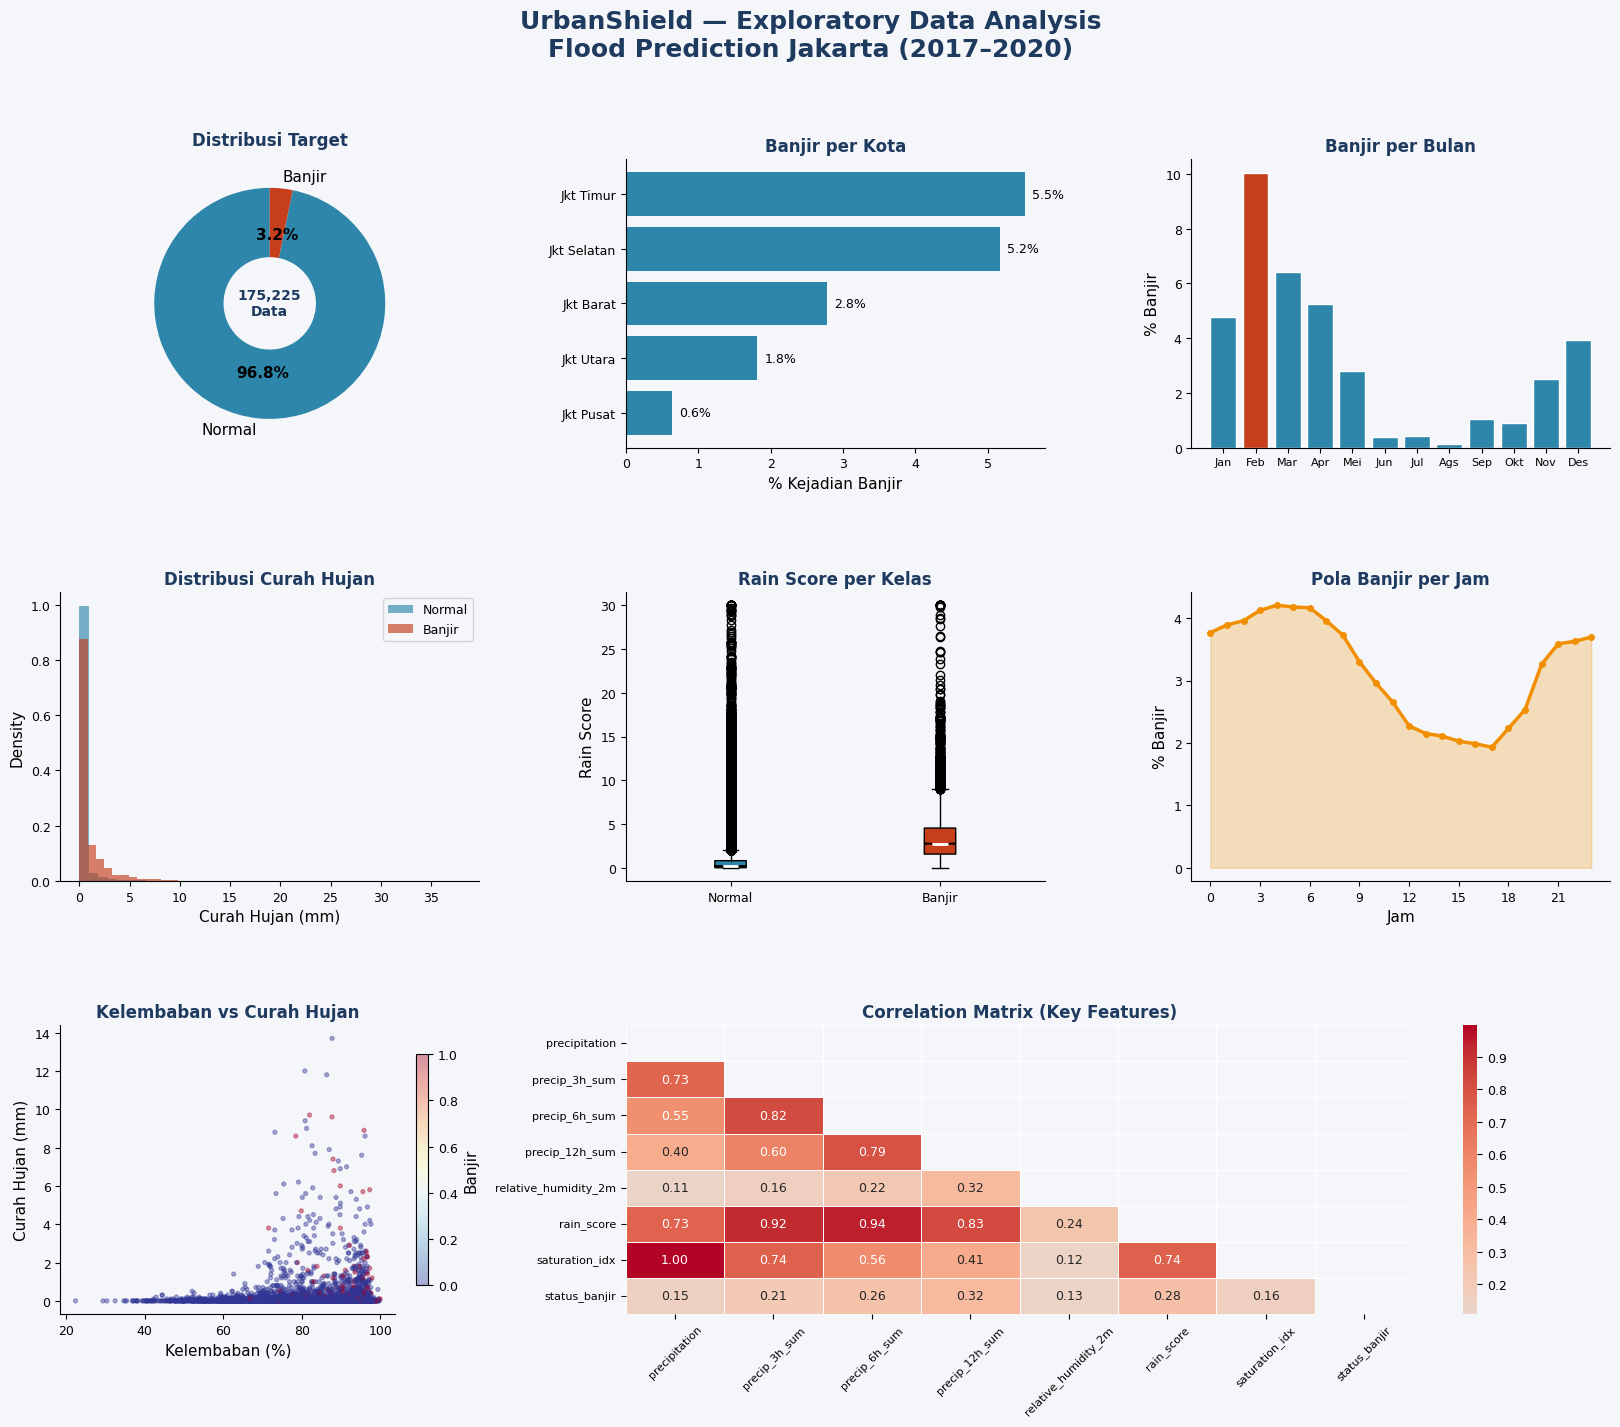

  ✓ EDA selesai & disimpan di folder ./visuals/


In [7]:
print("  STEP 4 — EDA VISUALISASI")

fig = plt.figure(figsize=(20, 15), facecolor=COLORS['light'])
fig.suptitle('UrbanShield — Exploratory Data Analysis\nFlood Prediction Jakarta (2017–2020)',
             fontsize=18, fontweight='bold', color=COLORS['primary'])
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# A: Donut target
ax = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax.pie(
    [vc[0], vc[1]], labels=['Normal', 'Banjir'],
    colors=[COLORS['secondary'], COLORS['danger']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.6), textprops={'fontsize': 11}
)
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Distribusi Target', fontweight='bold', color=COLORS['primary'], pad=10)
ax.text(0, 0, f'{len(df):,}\nData', ha='center', va='center',
        fontsize=10, fontweight='bold', color=COLORS['primary'])

# B: Banjir per kota
ax2 = fig.add_subplot(gs[0, 1])
kota_banjir = df.groupby('kota_administrasi')['status_banjir'].mean() * 100
kota_banjir = kota_banjir.sort_values()
kota_labels = [k.replace('jakarta ', 'Jkt ').title() for k in kota_banjir.index]
c_b = [COLORS['danger'] if v > 8 else COLORS['secondary'] for v in kota_banjir.values]
bars = ax2.barh(kota_labels, kota_banjir.values, color=c_b)
for bar, val in zip(bars, kota_banjir.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
ax2.set_xlabel('% Kejadian Banjir')
ax2.set_title('Banjir per Kota', fontweight='bold', color=COLORS['primary'])

# C: Banjir per bulan
ax3 = fig.add_subplot(gs[0, 2])
month_banjir = df.groupby('month')['status_banjir'].mean() * 100
month_names  = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
c_m = [COLORS['danger'] if v > 10 else COLORS['secondary'] for v in month_banjir.values]
ax3.bar(month_names, month_banjir.values, color=c_m, edgecolor='white')
ax3.set_ylabel('% Banjir')
ax3.set_title('Banjir per Bulan', fontweight='bold', color=COLORS['primary'])
ax3.tick_params(axis='x', labelsize=8)

# D: Distribusi curah hujan
ax4 = fig.add_subplot(gs[1, 0])
for label, color, name in [(0, COLORS['secondary'], 'Normal'), (1, COLORS['danger'], 'Banjir')]:
    subset = df[df['status_banjir'] == label]['precipitation'].clip(upper=40)
    ax4.hist(subset, bins=40, alpha=0.65, color=color, label=name, density=True)
ax4.set_xlabel('Curah Hujan (mm)'); ax4.set_ylabel('Density')
ax4.set_title('Distribusi Curah Hujan', fontweight='bold', color=COLORS['primary'])
ax4.legend(fontsize=9)

# E: Boxplot rain_score
ax5 = fig.add_subplot(gs[1, 1])
data_box = [
    df[df['status_banjir'] == 0]['rain_score'].clip(upper=30).values,
    df[df['status_banjir'] == 1]['rain_score'].clip(upper=30).values,
]
bp = ax5.boxplot(data_box, labels=['Normal', 'Banjir'], patch_artist=True, notch=True,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['secondary'])
bp['boxes'][1].set_facecolor(COLORS['danger'])
ax5.set_ylabel('Rain Score')
ax5.set_title('Rain Score per Kelas', fontweight='bold', color=COLORS['primary'])

# F: Pola banjir per jam
ax6 = fig.add_subplot(gs[1, 2])
hour_banjir = df.groupby('hour')['status_banjir'].mean() * 100
ax6.plot(hour_banjir.index, hour_banjir.values,
         color=COLORS['accent'], linewidth=2.5, marker='o', markersize=4)
ax6.fill_between(hour_banjir.index, hour_banjir.values, alpha=0.25, color=COLORS['accent'])
ax6.set_xlabel('Jam'); ax6.set_ylabel('% Banjir')
ax6.set_title('Pola Banjir per Jam', fontweight='bold', color=COLORS['primary'])
ax6.set_xticks(range(0, 24, 3))

# G: Scatter kelembaban vs curah hujan
ax7 = fig.add_subplot(gs[2, 0])
sample = df.sample(4000, random_state=RANDOM_SEED)
sc = ax7.scatter(sample['relative_humidity_2m'],
                 sample['precipitation'].clip(upper=30),
                 c=sample['status_banjir'], cmap='RdYlBu_r', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax7, shrink=0.8, label='Banjir')
ax7.set_xlabel('Kelembaban (%)'); ax7.set_ylabel('Curah Hujan (mm)')
ax7.set_title('Kelembaban vs Curah Hujan', fontweight='bold', color=COLORS['primary'])

# H: Correlation heatmap
ax8 = fig.add_subplot(gs[2, 1:])
key_cols = ['precipitation', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum',
            'relative_humidity_2m', 'rain_score', 'saturation_idx', 'status_banjir']
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax8, annot_kws={'size': 9}, linewidths=0.5)
ax8.set_title('Correlation Matrix (Key Features)', fontweight='bold', color=COLORS['primary'])
ax8.tick_params(axis='x', labelsize=8, rotation=45)
ax8.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig(VISUAL_DIR + '1_eda_overview.png', dpi=130) # DISABLED FOR EXPERIMENT
plt.show()
print(f"  ✓ EDA selesai & disimpan di folder {VISUAL_DIR}")

## 🧠 Chapter 7: Nowcasting Model Development (Step 5)
Melatih model XGBoost, LightGBM, dan Random Forest untuk prediksi banjir saat ini.

In [8]:
print("  STEP 5 — MODEL NOWCASTING (XGBOOST - 20 TRIALS - TS SPLIT)")

import optuna
import joblib
from sklearn.model_selection import TimeSeriesSplit

PRUNE_NOW = ['weather_code', 'wind_direction_10m']
CLEAN_COLS = [c for c in FEATURE_COLS_NOW if c not in PRUNE_NOW]

X_now = df[CLEAN_COLS]
y_now = df['status_banjir']

years_now = df['datetime'].dt.year
train_mask_now = years_now.isin([2017, 2018, 2019])
test_mask_now  = years_now == 2020

X_train_now = X_now[train_mask_now].reset_index(drop=True)
y_train_now = y_now[train_mask_now].reset_index(drop=True)
X_test_now  = X_now[test_mask_now].reset_index(drop=True)
y_test_now  = y_now[test_mask_now].reset_index(drop=True)

print(f"  Train: {len(X_train_now):,} | Test: {len(X_test_now):,}")

spw_now = (y_train_now == 0).sum() / (y_train_now == 1).sum() if (y_train_now == 1).sum() > 0 else 1

print("  Memulai Optuna Tuning Nowcast (20 Trials)...")
def obj_now(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw_now*0.8, spw_now*3.0),
        'gamma': trial.suggest_float('gamma', 0.0, 3.0),
        'eval_metric': 'logloss', 'random_state': RANDOM_SEED, 'verbosity': 0, 'n_jobs': -1
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_f1 = []
    for train_idx, val_idx in tscv.split(X_train_now):
        X_tr, X_v = X_train_now.iloc[train_idx], X_train_now.iloc[val_idx]
        y_tr, y_v = y_train_now.iloc[train_idx], y_train_now.iloc[val_idx]
        
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_v)
        cv_f1.append(f1_score(y_v, y_pred, pos_label=1))
        
    return np.mean(cv_f1)

study_now = optuna.create_study(direction='maximize')
study_now.optimize(obj_now, n_trials=20)

best_xgb_now = XGBClassifier(**study_now.best_params, eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0, n_jobs=-1)
best_xgb_now.fit(X_train_now, y_train_now)

p_t = best_xgb_now.predict_proba(X_test_now)[:, 1]
y_pred = best_xgb_now.predict(X_test_now)
auc = roc_auc_score(y_test_now, p_t)
f1 = f1_score(y_test_now, y_pred, pos_label=1)

print(f"  👑 CHAMPION NOWCAST: Test F1={f1:.4f} (AUC: {auc:.4f})")

best_now = {
    'model': best_xgb_now, 'y_prob': p_t, 'y_pred': y_pred,
    'cv_mean': study_now.best_value, 'cv_std': 0.0,
    'auc': auc, 'f1': f1, 'acc': accuracy_score(y_test_now, y_pred), 
    'thresh': 0.5, 'feat_names': CLEAN_COLS # Fixed Error here
}

# joblib.dump(best_xgb_now, OUTPUT_DIR + 'model_nowcast_xgboost.pkl') # DISABLED FOR EXPERIMENT
best_now_name = 'XGBoost'
nowcast_results = {'XGBoost': best_now} 


[I 2026-05-22 19:40:03,467] A new study created in memory with name: no-name-cf2e1ab7-7668-4d14-8e38-db6f71e267d3


  STEP 5 — MODEL NOWCASTING (XGBOOST - 20 TRIALS - TS SPLIT)
  Train: 131,305 | Test: 43,920
  Memulai Optuna Tuning Nowcast (20 Trials)...


[I 2026-05-22 19:40:08,303] Trial 0 finished with value: 0.19550999280097833 and parameters: {'n_estimators': 266, 'learning_rate': 0.048490823338617955, 'max_depth': 6, 'subsample': 0.8990106398227228, 'colsample_bytree': 0.6147989214271574, 'scale_pos_weight': 54.47828987742284, 'gamma': 0.4250614984863522}. Best is trial 0 with value: 0.19550999280097833.
[I 2026-05-22 19:40:13,296] Trial 1 finished with value: 0.18587559014517974 and parameters: {'n_estimators': 269, 'learning_rate': 0.02182717633893131, 'max_depth': 6, 'subsample': 0.8665669640930675, 'colsample_bytree': 0.871459519269283, 'scale_pos_weight': 96.90863106377958, 'gamma': 2.606244334353266}. Best is trial 0 with value: 0.19550999280097833.
[I 2026-05-22 19:40:16,578] Trial 2 finished with value: 0.18585547079765444 and parameters: {'n_estimators': 158, 'learning_rate': 0.021137802941540336, 'max_depth': 7, 'subsample': 0.7322808120540332, 'colsample_bytree': 0.7965569615557442, 'scale_pos_weight': 54.70284872240804,

  👑 CHAMPION NOWCAST: Test F1=0.3251 (AUC: 0.9079)


## 📈 Chapter 8: Forecasting Features (Step 6)
Menyiapkan fungsi untuk membuat fitur lag dan rolling untuk prediksi masa depan.

In [9]:
def make_forecast_features(df: pd.DataFrame, horizon_h: int) -> pd.DataFrame:
    rain_cols    = ['precipitation', 'precip_3h_sum', 'precip_6h_sum', 'precip_12h_sum', 'bogor_rain']
    weather_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure',
                    'wind_speed_10m', 'soil_temperature_0_to_7cm']

    dfs = []
    for kota, grp in df.groupby('kota_administrasi'):
        grp = grp.copy().sort_values('datetime').reset_index(drop=True)

        # TARGET: Status banjir X jam ke depan
        grp[f'target_{horizon_h}h'] = grp['status_banjir'].rolling(window=horizon_h, min_periods=1).max().shift(-horizon_h)

        # =============================================================
        # THE GONG: AUTOREGRESSIVE FEATURES (Flood Memory)
        # =============================================================
        grp['flood_current'] = grp['status_banjir'] # Kondisi banjir SAAT INI (Bukan Data Leakage untuk Forecasting!)
        grp['flood_lag3']    = grp['status_banjir'].shift(3)
        grp['flood_lag6']    = grp['status_banjir'].shift(6)
        grp['flood_lag12']   = grp['status_banjir'].shift(12)
        grp['flood_duration']= grp['status_banjir'].rolling(24, min_periods=1).sum() # Lama genangan dalam 24j terakhir

        # Hapus 'status_banjir' dari pembuatan fitur LAG cuaca
        for col in rain_cols:
            for lag in [1, 3, 6, 12]:
                grp[f'{col}_lag{lag}'] = grp[col].shift(lag)

        for col in weather_cols:
            for lag in [1, 3, 6]:
                grp[f'{col}_lag{lag}'] = grp[col].shift(lag)

        # ROLLING features
        for col in rain_cols:
            for win in [3, 6, 12]:
                shifted = grp[col].shift(1)
                grp[f'{col}_roll{win}_mean'] = shifted.rolling(win).mean()
                grp[f'{col}_roll{win}_max']  = shifted.rolling(win).max()
                grp[f'{col}_roll{win}_std']  = shifted.rolling(win).std()

        # LONG-TERM MEMORY FEATURES (24h, 48h, 72h)
        for win in [24, 48, 72]:
            grp[f'precip_{win}h_sum'] = grp['precipitation'].shift(1).rolling(win).sum()
            grp[f'bogor_rain_roll{win}_sum'] = grp['bogor_rain'].shift(1).rolling(win).sum()

        for col in ['relative_humidity_2m', 'temperature_2m', 'surface_pressure']:
            for win in [3, 6]:
                grp[f'{col}_roll{win}_mean'] = grp[col].shift(1).rolling(win).mean()

        grp['precip_trend_3h']   = grp['precipitation'] - grp['precipitation'].shift(3)
        grp['precip_trend_6h']   = grp['precipitation'] - grp['precipitation'].shift(6)
        
        # ADVANCED FEATURES
        grp['pressure_drop_3h']  = grp['surface_pressure'] - grp['surface_pressure'].shift(3)
        grp['pressure_drop_6h']  = grp['surface_pressure'] - grp['surface_pressure'].shift(6)
        grp['soil_saturation']   = grp['soil_temperature_0_to_7cm'] * (grp['precip_12h_sum'] + 1)
        grp['soil_saturation_deep'] = grp['soil_temperature_0_to_7cm'] * (grp['precip_72h_sum'] + 1)
        
        grp['is_raining']  = (grp['precipitation'] > 0).astype(int)
        grp['consec_rain'] = grp['is_raining'].groupby(
            (grp['is_raining'] != grp['is_raining'].shift()).cumsum()
        ).cumcount()

        grp['rain_score']     = (grp['precipitation'] * 0.4 + grp['precip_3h_sum'] * 0.3 +
                                  grp['precip_6h_sum'] * 0.2 + grp['precip_12h_sum'] * 0.1)
        grp['saturation_idx'] = grp['relative_humidity_2m'] * grp['precipitation'] / 100
        grp['heavy_rain']     = (grp['precipitation'] > grp['precipitation'].quantile(0.90)).astype(int)

        dfs.append(grp)

    result = pd.concat(dfs, ignore_index=True)
    result = result.dropna()
    return result

## 🚀 Chapter 9: Model Forecasting Training (Step 7)
Melatih model untuk horizon +3h, +6h, dan +12h.

In [10]:
print("  STEP 7 — CHAMPION MODEL HOURLY (+3h / +6h / +12h) - 20 TRIALS")

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
import os
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
EXCLUDE_COLS  = ['datetime', 'tanggal', 'jam', 'kota_administrasi', 'status_banjir', 'weather_code', 'wind_direction_10m']
ALL_TARGETS   = [f'target_{h}h' for h in HORIZONS]

MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
forecast_results = {}

for H in HORIZONS:
    print(f"\n{'='*60}")
    print(f"Tuning XGBoost Horizon +{H} Jam")
    
    dfh = make_forecast_features(df, H)
    target_col = f'target_{H}h'
    feat_cols = [c for c in dfh.columns if c not in EXCLUDE_COLS + ALL_TARGETS and dfh[c].dtype != object]
    
    years = dfh['datetime'].dt.year
    train_mask = years.isin([2017, 2018, 2019])
    test_mask  = years == 2020
    
    X_train = dfh.loc[train_mask, feat_cols].reset_index(drop=True)
    y_train = dfh.loc[train_mask, target_col].astype(int).reset_index(drop=True)
    X_test  = dfh.loc[test_mask, feat_cols].reset_index(drop=True)
    y_test  = dfh.loc[test_mask, target_col].astype(int).reset_index(drop=True)
    
    spw = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

    def obj_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw*0.8, spw*3.0),
            'gamma': trial.suggest_float('gamma', 0.0, 3.0),
            'eval_metric': 'logloss', 'random_state': RANDOM_SEED, 'verbosity': 0, 'n_jobs': -1
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        cv_f1 = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_v)
            cv_f1.append(f1_score(y_v, y_pred, pos_label=1))
        return np.mean(cv_f1)
    
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(obj_xgb, n_trials=20)
    
    champion_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0, n_jobs=-1)
    champion_xgb.fit(X_train, y_train)
    
    p_test = champion_xgb.predict_proba(X_test)[:, 1]
    y_pred = champion_xgb.predict(X_test)
    
    auc = roc_auc_score(y_test, p_test)
    f1_test = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"  👑 XGBOOST +{H}h: Test F1={f1_test:.4f} (AUC: {auc:.4f})")
    prec_c, rec_c, thrs = precision_recall_curve(y_test, p_test)
    
    forecast_results[H] = {
        'auc': auc, 'f1': f1_test, 'prec': prec, 'rec': rec, 'acc': acc,
        'thresh': 0.5, 'y_test': y_test, 'y_prob': p_test, 
        'y_pred_opt': y_pred, 'model': champion_xgb,
        'fi': champion_xgb.feature_importances_,
        'prec_curve': prec_c, 'rec_curve': rec_c, 'thrs': thrs,
        'feat_names': list(X_train.columns)
    }
#     joblib.dump(champion_xgb, os.path.join(MODEL_DIR, f'champion_forecast_{H}h.pkl')) # DISABLED FOR EXPERIMENT
#     joblib.dump(forecast_results[H], os.path.join(MODEL_DIR, f'meta_{H}h.pkl')) # DISABLED FOR EXPERIMENT

  STEP 7 — CHAMPION MODEL HOURLY (+3h / +6h / +12h) - 20 TRIALS

Tuning XGBoost Horizon +3 Jam
  👑 XGBOOST +3h: Test F1=0.8473 (AUC: 0.9824)

Tuning XGBoost Horizon +6 Jam
  👑 XGBOOST +6h: Test F1=0.7457 (AUC: 0.9615)

Tuning XGBoost Horizon +12 Jam
  👑 XGBOOST +12h: Test F1=0.6824 (AUC: 0.9152)


In [11]:
# =========================================================================================
# EKSPERIMEN: PREDIKSI HARIAN (1-DAY AHEAD)
# =========================================================================================
print("  STEP 7.5 — EKSPERIMEN: PREDIKSI HARIAN (1-DAY AHEAD)")

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

# 1. Agregasi Harian (Daily)
df_daily = df.groupby(['kota_administrasi', 'tanggal']).agg({
    'precipitation': 'sum',
    'bogor_rain': 'sum',
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'surface_pressure': 'mean',
    'soil_temperature_0_to_7cm': 'mean',
    'status_banjir': 'max' # Jika ada 1 jam saja banjir di hari itu, maka hari itu dianggap banjir
}).reset_index()

df_daily['tanggal'] = pd.to_datetime(df_daily['tanggal'])
df_daily = df_daily.sort_values(by=['kota_administrasi', 'tanggal']).reset_index(drop=True)

dfs_d = []
for kota, grp in df_daily.groupby('kota_administrasi'):
    # TARGET: Apakah besok banjir? (Shift -1 hari)
    grp['target_1day_ahead'] = grp['status_banjir'].shift(-1)
    
    # Fitur Harian
    grp['precip_lag1d'] = grp['precipitation'].shift(1)
    grp['bogor_lag1d']  = grp['bogor_rain'].shift(1)
    grp['precip_3d_sum'] = grp['precipitation'].rolling(3).sum()
    grp['bogor_3d_sum']  = grp['bogor_rain'].rolling(3).sum()
    grp['soil_lag1d']   = grp['soil_temperature_0_to_7cm'].shift(1)
    
    dfs_d.append(grp)

df_daily_feat = pd.concat(dfs_d, ignore_index=True).dropna()

# 2. Split (2017-2019 vs 2020)
years_d = df_daily_feat['tanggal'].dt.year
train_mask_d = years_d.isin([2017, 2018, 2019])
test_mask_d  = years_d == 2020

feat_cols_d = ['precipitation', 'bogor_rain', 'temperature_2m', 'relative_humidity_2m', 
               'surface_pressure', 'soil_temperature_0_to_7cm', 'precip_lag1d', 'bogor_lag1d', 
               'precip_3d_sum', 'bogor_3d_sum', 'soil_lag1d']

X_tr_d = df_daily_feat.loc[train_mask_d, feat_cols_d].reset_index(drop=True)
y_tr_d = df_daily_feat.loc[train_mask_d, 'target_1day_ahead'].astype(int).reset_index(drop=True)
X_ts_d = df_daily_feat.loc[test_mask_d, feat_cols_d].reset_index(drop=True)
y_ts_d = df_daily_feat.loc[test_mask_d, 'target_1day_ahead'].astype(int).reset_index(drop=True)

print(f"  Total Data Harian -> Train: {len(X_tr_d)} hari | Test: {len(X_ts_d)} hari")

# 3. Model Training
spw_d = (y_tr_d == 0).sum() / (y_tr_d == 1).sum() if (y_tr_d == 1).sum() > 0 else 1

def obj_daily(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw_d*0.5, spw_d*2.0),
        'eval_metric': 'logloss', 'random_state': RANDOM_SEED, 'verbosity': 0
    }
    tscv = TimeSeriesSplit(n_splits=3)
    cv_f1 = []
    for train_idx, val_idx in tscv.split(X_tr_d):
        X_t, X_v = X_tr_d.iloc[train_idx], X_tr_d.iloc[val_idx]
        y_t, y_v = y_tr_d.iloc[train_idx], y_tr_d.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(X_t, y_t)
        y_p = model.predict(X_v)
        cv_f1.append(f1_score(y_v, y_p, pos_label=1))
    return np.mean(cv_f1)

study_d = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_d.optimize(obj_daily, n_trials=20)

daily_xgb = XGBClassifier(**study_d.best_params, eval_metric='logloss', random_state=RANDOM_SEED)
daily_xgb.fit(X_tr_d, y_tr_d)

p_ts_d = daily_xgb.predict_proba(X_ts_d)[:, 1]
y_pred_d = daily_xgb.predict(X_ts_d)
f1_d = f1_score(y_ts_d, y_pred_d, pos_label=1)
auc_d = roc_auc_score(y_ts_d, p_ts_d)

print(f"\n  🌟 HASIL PREDIKSI HARIAN (+1 HARI / +24 JAM):")
print(f"  F1-Score : {f1_d:.4f}")
print(f"  AUC-ROC  : {auc_d:.4f}")
print(f"  Recall   : {recall_score(y_ts_d, y_pred_d):.4f}")
print(f"  Precision: {precision_score(y_ts_d, y_pred_d):.4f}")

# Simpan ke forecast results agar divisualisasikan juga
prec_c_d, rec_c_d, thrs_d = precision_recall_curve(y_ts_d, p_ts_d)
forecast_results[24] = {
    'auc': auc_d, 'f1': f1_d, 'prec': precision_score(y_ts_d, y_pred_d), 
    'rec': recall_score(y_ts_d, y_pred_d), 'acc': accuracy_score(y_ts_d, y_pred_d),
    'thresh': 0.5, 'y_test': y_ts_d, 'y_prob': p_ts_d, 
    'y_pred_opt': y_pred_d, 'model': daily_xgb,
    'fi': daily_xgb.feature_importances_,
    'prec_curve': prec_c_d, 'rec_curve': rec_c_d, 'thrs': thrs_d,
    'feat_names': list(X_tr_d.columns)
}
# joblib.dump(daily_xgb, os.path.join(MODEL_DIR, f'champion_forecast_24h.pkl')) # DISABLED FOR EXPERIMENT
# joblib.dump(forecast_results[24], os.path.join(MODEL_DIR, f'meta_24h.pkl')) # DISABLED FOR EXPERIMENT
HORIZONS.append(24)
HORIZON_COLORS[24] = '#10B981' # Green color for daily


  STEP 7.5 — EKSPERIMEN: PREDIKSI HARIAN (1-DAY AHEAD)
  Total Data Harian -> Train: 5465 hari | Test: 1825 hari

  🌟 HASIL PREDIKSI HARIAN (+1 HARI / +24 JAM):
  F1-Score : 0.2176
  AUC-ROC  : 0.6606
  Recall   : 0.5497
  Precision: 0.1356


## 🏆 Chapter 10: Final Evaluation (Step 8 & 9)
Scorecard akhir dan evaluasi performa.

  STEP 8 — VISUALISASI EVALUASI NOWCASTING


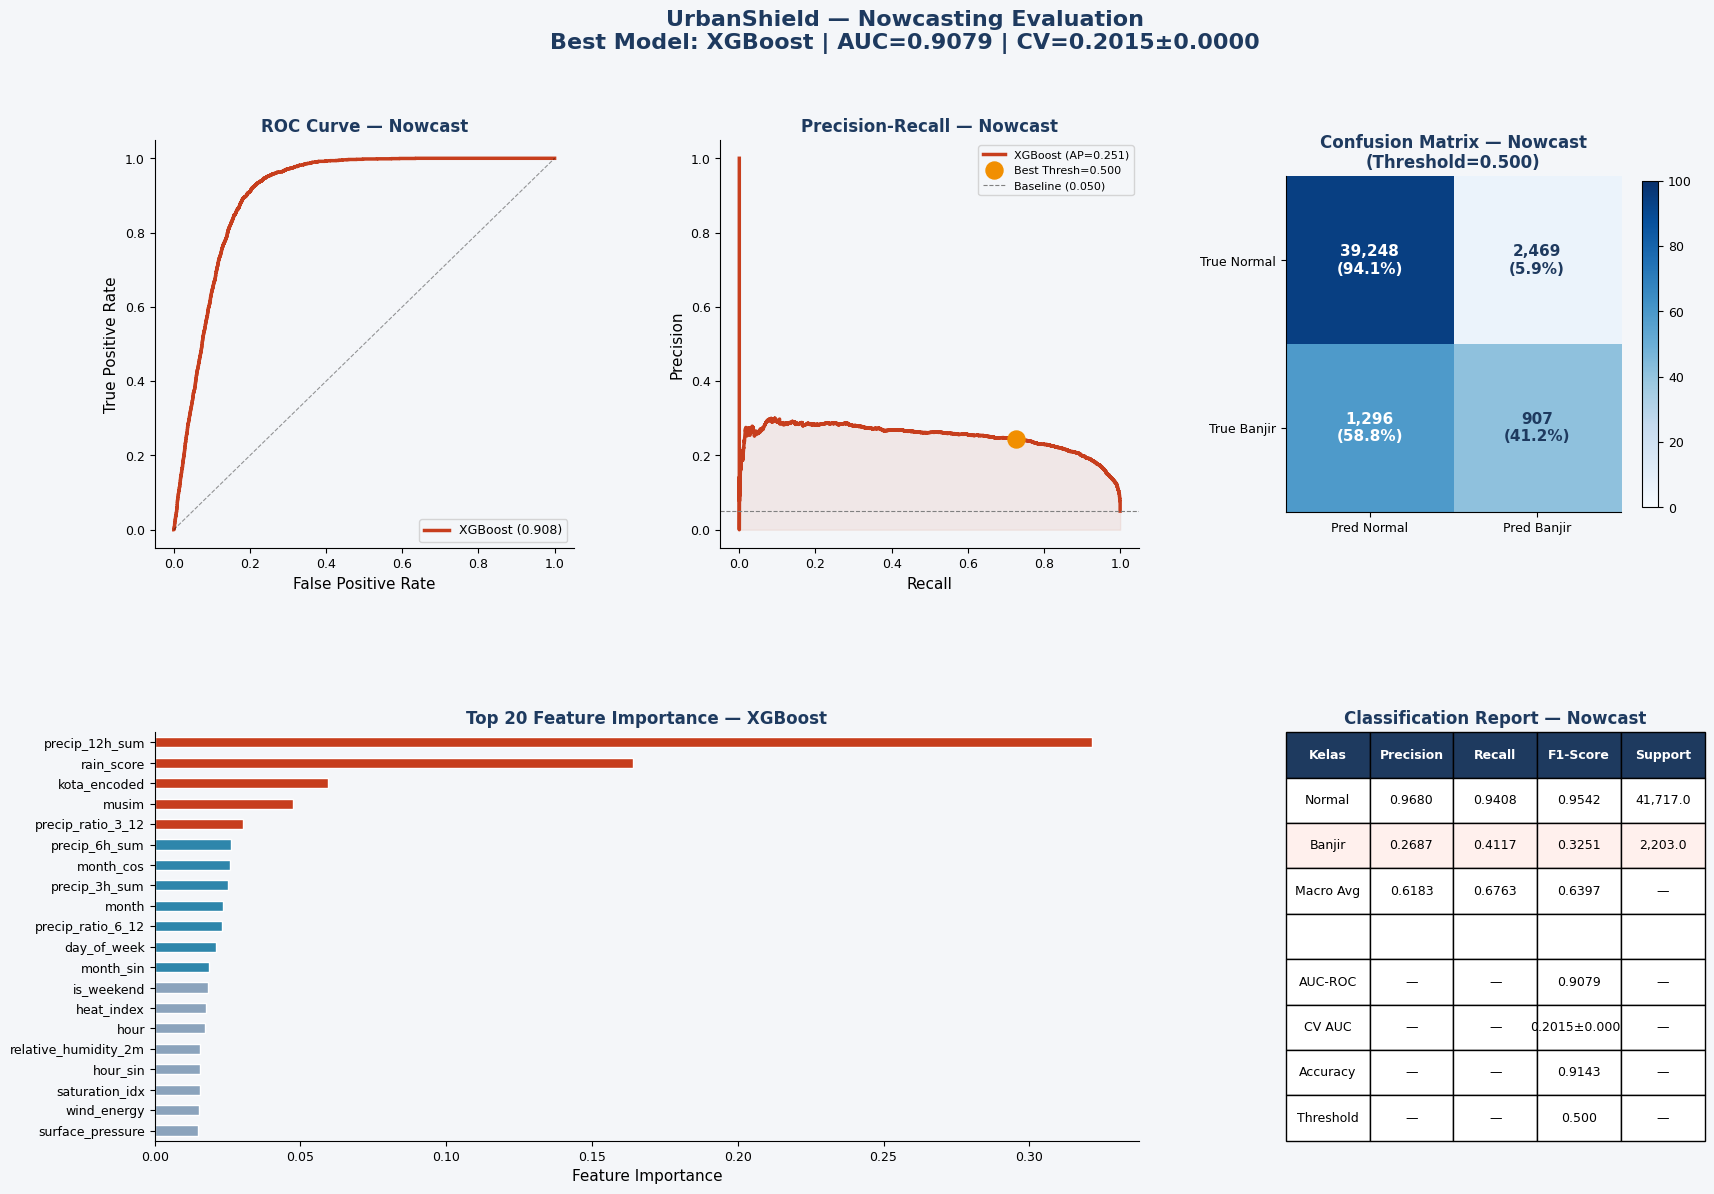

  ✓ Saved → 2_nowcast_evaluation.png


In [12]:
print("  STEP 8 — VISUALISASI EVALUASI NOWCASTING")

fig2 = plt.figure(figsize=(20, 13), facecolor=COLORS['light'])
fig2.suptitle(
    f'UrbanShield — Nowcasting Evaluation\n'
    f'Best Model: {best_now_name} | AUC={best_now["auc"]:.4f} | '
    f'CV={best_now["cv_mean"]:.4f}±{best_now["cv_std"]:.4f}',
    fontsize=16, fontweight='bold', color=COLORS['primary']
)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)

# A: ROC Curve semua model nowcast
ax = fig2.add_subplot(gs2[0, 0])
nc_colors = [COLORS['danger'], COLORS['secondary'], COLORS['accent']]
for (name, res), col in zip(nowcast_results.items(), nc_colors):
    fpr, tpr, _ = roc_curve(y_test_now, res['y_prob'])
    lw = 2.5 if name == best_now_name else 1.5
    ax.plot(fpr, tpr, color=col, linewidth=lw,
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Nowcast', fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9)

# B: Precision-Recall Curve
ax2b = fig2.add_subplot(gs2[0, 1])
prec_c, rec_c, thrs_b = precision_recall_curve(y_test_now, best_now['y_prob'])
f1s_b     = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
best_idx  = np.argmax(f1s_b)
ap        = average_precision_score(y_test_now, best_now['y_prob'])
ax2b.plot(rec_c, prec_c, color=COLORS['danger'], linewidth=2.5,
          label=f'{best_now_name} (AP={ap:.3f})')
ax2b.scatter(rec_c[best_idx], prec_c[best_idx],
             color=COLORS['accent'], s=150, zorder=5,
             label=f'Best Thresh={best_now["thresh"]:.3f}')
ax2b.axhline(y_test_now.mean(), color='gray', linestyle='--', linewidth=0.8,
             label=f'Baseline ({y_test_now.mean():.3f})')
ax2b.fill_between(rec_c, prec_c, alpha=0.08, color=COLORS['danger'])
ax2b.set_xlabel('Recall'); ax2b.set_ylabel('Precision')
ax2b.set_title('Precision-Recall — Nowcast', fontweight='bold', color=COLORS['primary'])
ax2b.legend(fontsize=8)

# C: Confusion Matrix nowcast
ax3b = fig2.add_subplot(gs2[0, 2])
cm    = confusion_matrix(y_test_now, best_now['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im = ax3b.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        ax3b.text(j, i, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                  ha='center', va='center', fontsize=11, fontweight='bold',
                  color='white' if cm_pct[i,j] > 55 else COLORS['primary'])
ax3b.set_xticks([0,1]); ax3b.set_yticks([0,1])
ax3b.set_xticklabels(['Pred Normal','Pred Banjir'], fontsize=9)
ax3b.set_yticklabels(['True Normal','True Banjir'], fontsize=9)
ax3b.set_title(f'Confusion Matrix — Nowcast\n(Threshold={best_now["thresh"]:.3f})',
               fontweight='bold', color=COLORS['primary'])
plt.colorbar(im, ax=ax3b, shrink=0.8)

# D: Feature Importance
ax4b = fig2.add_subplot(gs2[1, 0:2])
if hasattr(best_now['model'], 'feature_importances_'):
    fi = pd.Series(best_now['model'].feature_importances_,
                   index=CLEAN_COLS).nlargest(20)
    c_fi = [COLORS['danger'] if i<5 else COLORS['secondary'] if i<12 else COLORS['mid']
            for i in range(len(fi))]
    fi[::-1].plot(kind='barh', ax=ax4b, color=c_fi[::-1], edgecolor='white')
    ax4b.set_xlabel('Feature Importance')
    ax4b.set_title(f'Top 20 Feature Importance — {best_now_name}',
                   fontweight='bold', color=COLORS['primary'])
    ax4b.tick_params(axis='y', labelsize=9)

# E: Classification Report Table
ax5b = fig2.add_subplot(gs2[1, 2])
ax5b.axis('off')
report = classification_report(y_test_now, best_now['y_pred'],
                               target_names=['Normal','Banjir'], output_dict=True)
tbl_data = [
    ['Kelas',     'Precision', 'Recall', 'F1-Score', 'Support'],
    ['Normal',    f"{report['Normal']['precision']:.4f}",
                  f"{report['Normal']['recall']:.4f}",
                  f"{report['Normal']['f1-score']:.4f}",
                  f"{report['Normal']['support']:,}"],
    ['Banjir',    f"{report['Banjir']['precision']:.4f}",
                  f"{report['Banjir']['recall']:.4f}",
                  f"{report['Banjir']['f1-score']:.4f}",
                  f"{report['Banjir']['support']:,}"],
    ['Macro Avg', f"{report['macro avg']['precision']:.4f}",
                  f"{report['macro avg']['recall']:.4f}",
                  f"{report['macro avg']['f1-score']:.4f}", '—'],
    ['',          '',          '',        '',          ''],
    ['AUC-ROC',   '—', '—', f"{best_now['auc']:.4f}",   '—'],
    ['CV AUC',    '—', '—', f"{best_now['cv_mean']:.4f}±{best_now['cv_std']:.4f}", '—'],
    ['Accuracy',  '—', '—', f"{report['accuracy']:.4f}", '—'],
    ['Threshold', '—', '—', f"{best_now['thresh']:.3f}", '—'],
]
tbl = ax5b.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for j in range(5):
    tbl[0, j].set_facecolor(COLORS['primary'])
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for j in range(5):
    tbl[2, j].set_facecolor('#FFF0ED')
ax5b.set_title('Classification Report — Nowcast',
               fontweight='bold', color=COLORS['primary'])

plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig(VISUAL_DIR + '2_nowcast_evaluation.png', dpi=130, bbox_inches='tight') # DISABLED FOR EXPERIMENT
plt.show()
print(f"  ✓ Saved → 2_nowcast_evaluation.png")


  STEP 9 — VISUALISASI EVALUASI FORECASTING


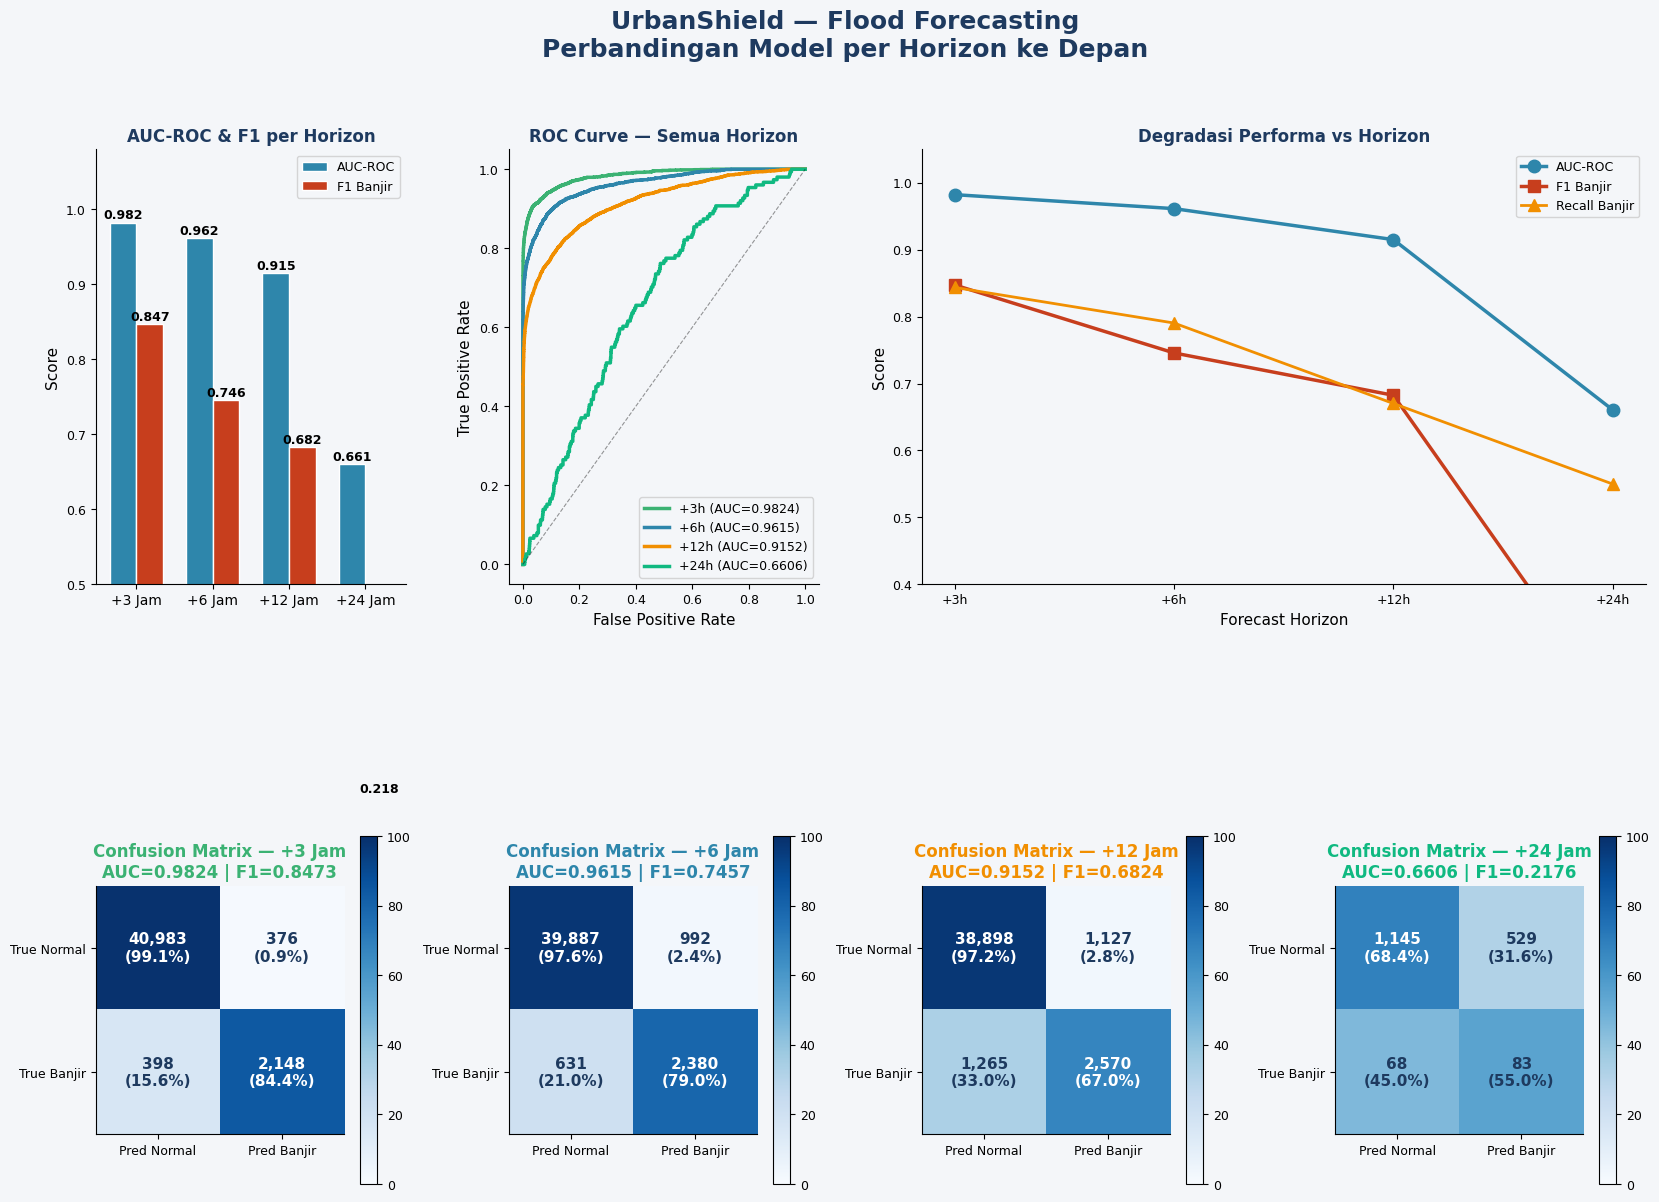

  ✓ Saved → 3_forecast_evaluation.png


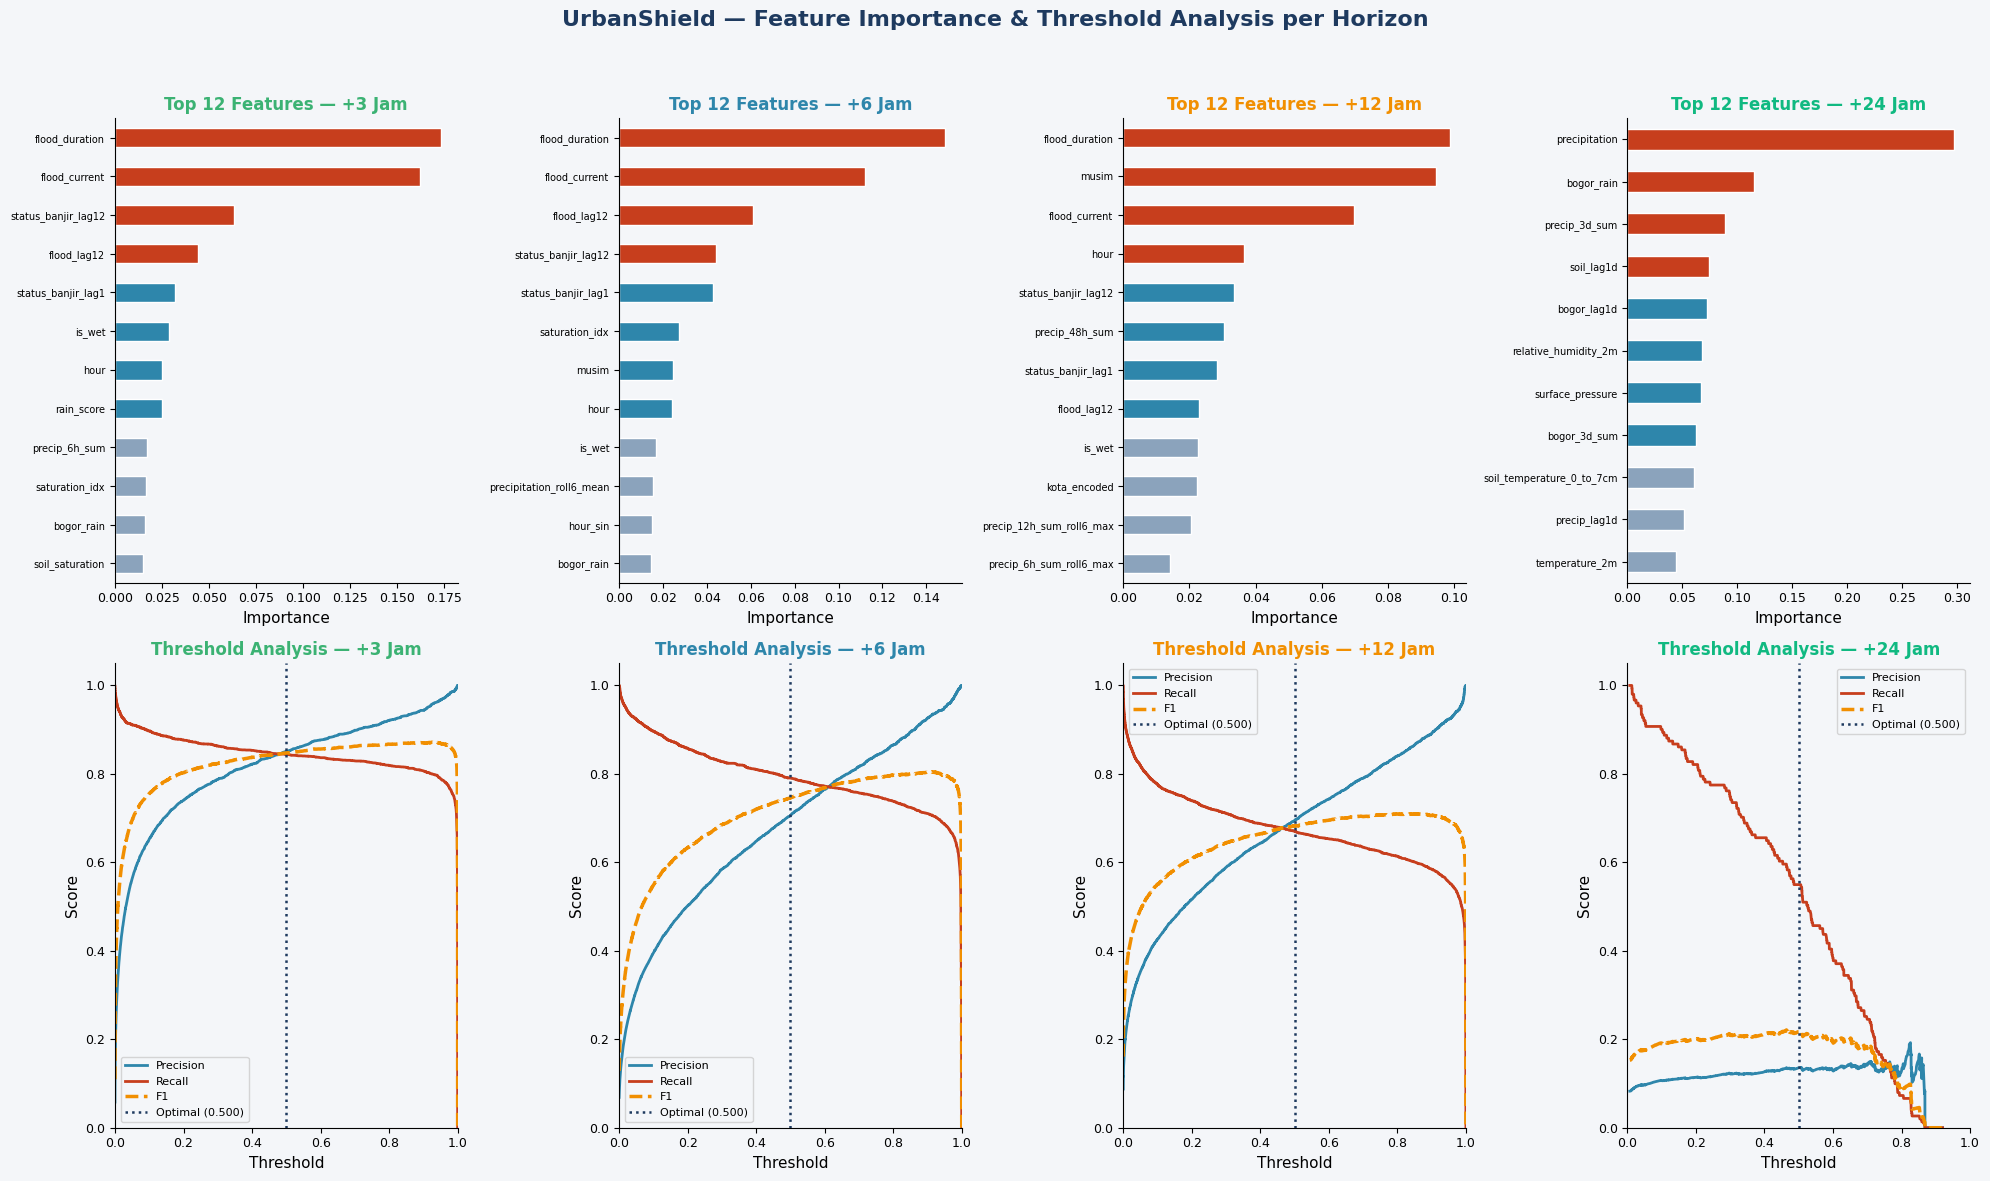

  ✓ Saved → 4_feature_threshold_analysis.png


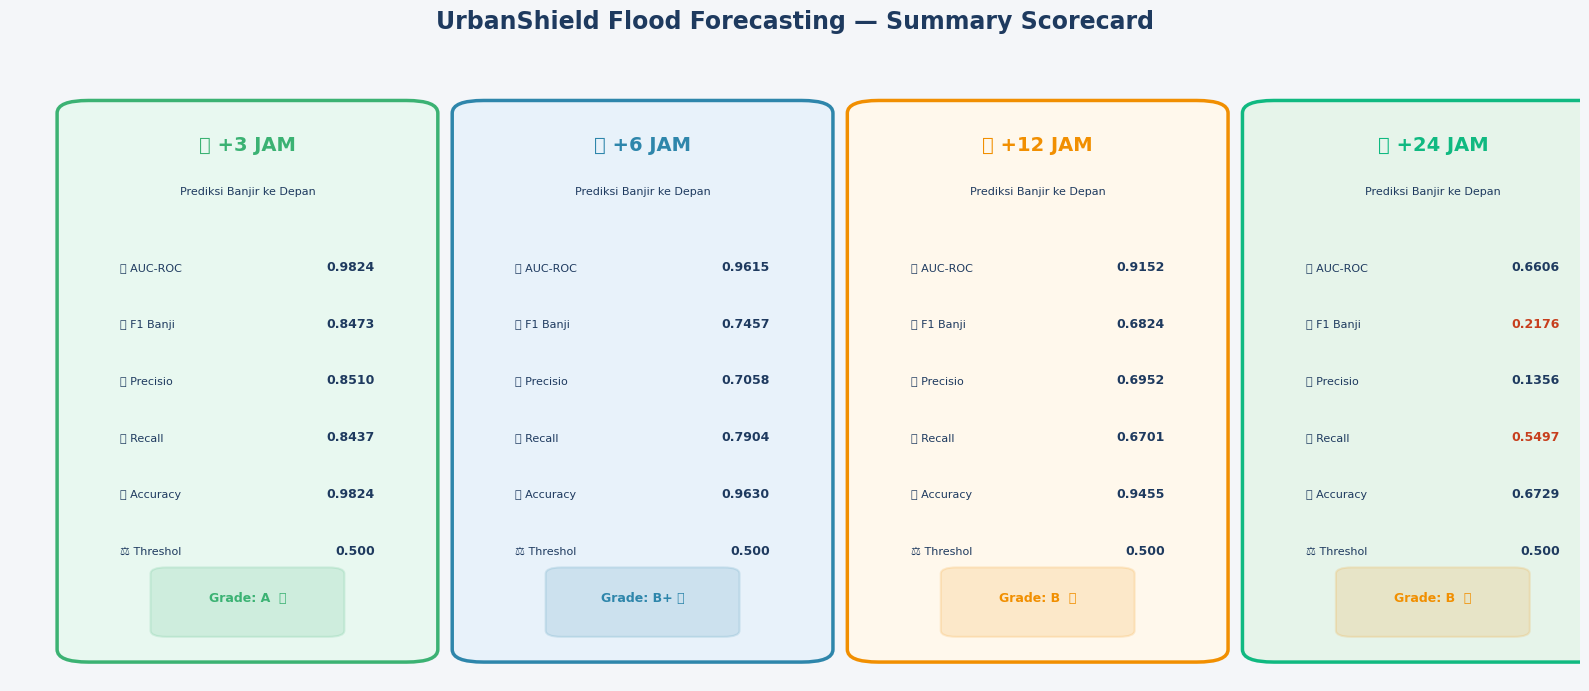

  ✓ Saved → 5_scorecard.png


In [13]:
print("  STEP 9 — VISUALISASI EVALUASI FORECASTING")

fig3 = plt.figure(figsize=(20, 14), facecolor=COLORS['light'])
fig3.suptitle('UrbanShield — Flood Forecasting\nPerbandingan Model per Horizon ke Depan',
              fontsize=18, fontweight='bold', color=COLORS['primary'])
gs3 = gridspec.GridSpec(2, len(HORIZONS), figure=fig3, hspace=0.48, wspace=0.33)

aucs_fc = [forecast_results[h]['auc'] for h in HORIZONS]
f1s_fc  = [forecast_results[h]['f1']  for h in HORIZONS]
recs_fc = [forecast_results[h]['rec'] for h in HORIZONS]

# A: Bar AUC & F1
ax = fig3.add_subplot(gs3[0, 0])
x, w = np.arange(len(HORIZONS)), 0.35
b1 = ax.bar(x-w/2, aucs_fc, w, label='AUC-ROC',   color=COLORS['secondary'], edgecolor='white')
b2 = ax.bar(x+w/2, f1s_fc,  w, label='F1 Banjir', color=COLORS['danger'],   edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'+{h} Jam' if h != 24 else '+24 Jam' for h in HORIZONS], fontsize=10)
ax.set_ylim(0.5, 1.08); ax.set_ylabel('Score')
ax.set_title('AUC-ROC & F1 per Horizon', fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9)

# B: ROC Curve semua horizon
ax2c = fig3.add_subplot(gs3[0, 1])
for h in HORIZONS:
    fpr, tpr, _ = roc_curve(forecast_results[h]['y_test'], forecast_results[h]['y_prob'])
    ax2c.plot(fpr, tpr, color=HORIZON_COLORS[h], linewidth=2.5,
              label=f'+{h}h (AUC={forecast_results[h]["auc"]:.4f})')
ax2c.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)
ax2c.set_xlabel('False Positive Rate'); ax2c.set_ylabel('True Positive Rate')
ax2c.set_title('ROC Curve — Semua Horizon', fontweight='bold', color=COLORS['primary'])
ax2c.legend(fontsize=9)

# C: Degradasi performa
ax3c = fig3.add_subplot(gs3[0, 2:])
h_labels = [f'+{h}h' for h in HORIZONS]
ax3c.plot(h_labels, aucs_fc, 'o-', color=COLORS['secondary'], lw=2.5, ms=9, label='AUC-ROC')
ax3c.plot(h_labels, f1s_fc,  's-', color=COLORS['danger'],    lw=2.5, ms=9, label='F1 Banjir')
ax3c.plot(h_labels, recs_fc, '^-', color=COLORS['accent'],    lw=2,   ms=9, label='Recall Banjir')
ax3c.set_ylim(0.4, 1.05); ax3c.set_ylabel('Score')
ax3c.set_title('Degradasi Performa vs Horizon', fontweight='bold', color=COLORS['primary'])
ax3c.legend(fontsize=9); ax3c.set_xlabel('Forecast Horizon')

# D, E, F: Confusion Matrix per horizon
for idx, H in enumerate(HORIZONS):
    ax = fig3.add_subplot(gs3[1, idx])
    cm    = confusion_matrix(forecast_results[H]['y_test'], forecast_results[H]['y_pred_opt'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if cm_pct[i,j] > 55 else COLORS['primary'])
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Normal','Pred Banjir'], fontsize=9)
    ax.set_yticklabels(['True Normal','True Banjir'], fontsize=9)
    ax.set_title(f'Confusion Matrix — +{H} Jam\nAUC={forecast_results[H]["auc"]:.4f} '
                 f'| F1={forecast_results[H]["f1"]:.4f}',
                 fontweight='bold', color=HORIZON_COLORS[H])
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(VISUAL_DIR + '3_forecast_evaluation.png', dpi=130, bbox_inches='tight') # DISABLED FOR EXPERIMENT
plt.show()
print(f"  ✓ Saved → 3_forecast_evaluation.png")

# ── Feature importance per horizon ──
fig4, axes4 = plt.subplots(2, len(HORIZONS), figsize=(20, 12), facecolor=COLORS['light'])
fig4.suptitle('UrbanShield — Feature Importance & Threshold Analysis per Horizon',
              fontsize=16, fontweight='bold', color=COLORS['primary'])

for idx, H in enumerate(HORIZONS):
    R = forecast_results[H]

    # Feature importance (top 12)
    ax = axes4[0, idx]
    ax.set_facecolor(COLORS['light'])
    fi = pd.Series(R['fi'], index=R['feat_names']).nlargest(12)
    c_fi = [COLORS['danger'] if i<4 else COLORS['secondary'] if i<8 else COLORS['mid']
            for i in range(len(fi))]
    fi[::-1].plot(kind='barh', ax=ax, color=c_fi[::-1], edgecolor='white')
    ax.set_title(f'Top 12 Features — +{H} Jam', fontweight='bold', color=HORIZON_COLORS[H])
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=7)
    ax.spines[['top','right']].set_visible(False)

    # Threshold analysis
    ax2 = axes4[1, idx]
    ax2.set_facecolor(COLORS['light'])
    f1s_thr = 2*R['prec_curve'][:-1]*R['rec_curve'][:-1]/(R['prec_curve'][:-1]+R['rec_curve'][:-1]+1e-8)
    ax2.plot(R['thrs'], R['prec_curve'][:-1], color=COLORS['secondary'], lw=2, label='Precision')
    ax2.plot(R['thrs'], R['rec_curve'][:-1],  color=COLORS['danger'],    lw=2, label='Recall')
    ax2.plot(R['thrs'], f1s_thr,              color=COLORS['accent'],    lw=2.5, ls='--', label='F1')
    ax2.axvline(R['thresh'], color=COLORS['primary'], lw=1.8, ls=':',
                label=f'Optimal ({R["thresh"]:.3f})')
    ax2.set_xlim(0,1); ax2.set_ylim(0,1.05)
    ax2.set_xlabel('Threshold'); ax2.set_ylabel('Score')
    ax2.set_title(f'Threshold Analysis — +{H} Jam', fontweight='bold', color=HORIZON_COLORS[H])
    ax2.legend(fontsize=8)
    ax2.spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.95])
# plt.savefig(VISUAL_DIR + '4_feature_threshold_analysis.png', dpi=130, bbox_inches='tight') # DISABLED FOR EXPERIMENT
plt.show()
print(f"  ✓ Saved → 4_feature_threshold_analysis.png")

# ── Scorecard ──
fig5, ax_sc = plt.subplots(figsize=(16, 7), facecolor=COLORS['light'])
ax_sc.axis('off')
fig5.suptitle('UrbanShield Flood Forecasting — Summary Scorecard',
              fontsize=17, fontweight='bold', color=COLORS['primary'], y=0.98)

h_bg = {3:'#E8F8F0', 6:'#E8F2FA', 12:'#FFF8EC', 24:'#E6F4EA'}
h_hd = {3:COLORS['success'], 6:COLORS['secondary'], 12:COLORS['accent'], 24:'#10B981'}

N = len(HORIZONS)
card_width = 0.90 / N
spacing = 0.08 / (N - 1) if N > 1 else 0.08

for idx, H in enumerate(HORIZONS):
    R   = forecast_results[H]
    x0  = 0.05 + idx * (card_width + spacing)
    rect = mpatches.FancyBboxPatch((x0, 0.05), card_width * 0.9, 0.85,
                                    boxstyle='round,pad=0.02',
                                    facecolor=h_bg.get(H, '#F4F6F9'), edgecolor=h_hd.get(H, COLORS['primary']), linewidth=2.5,
                                    transform=ax_sc.transAxes)
    ax_sc.add_patch(rect)
    ax_sc.text(x0 + card_width*0.45, 0.84, f'⏰ +{H} JAM' if H != 24 else '⏰ +24 JAM', ha='center', fontsize=18 if N <= 3 else 14,
               fontweight='bold', color=h_hd.get(H, COLORS['primary']), transform=ax_sc.transAxes)
    ax_sc.text(x0 + card_width*0.45, 0.77, 'Prediksi Banjir ke Depan', ha='center', fontsize=10 if N <= 3 else 8,
               color=COLORS['primary'], transform=ax_sc.transAxes)

    metrics = [
        ('AUC-ROC',   f"{R['auc']:.4f}",   '🎯'),
        ('F1 Banjir', f"{R['f1']:.4f}",    '🌊'),
        ('Precision', f"{R['prec']:.4f}",  '🔍'),
        ('Recall',    f"{R['rec']:.4f}",   '📡'),
        ('Accuracy',  f"{R['acc']:.4f}",   '✅'),
        ('Threshold', f"{R['thresh']:.3f}",'⚖️'),
    ]
    for mi, (mname, mval, icon) in enumerate(metrics):
        y_pos = 0.65 - mi * 0.09
        ax_sc.text(x0 + card_width*0.09, y_pos, f'{icon} {mname}' if N <= 3 else f'{icon} {mname[:8]}', ha='left', fontsize=10 if N <= 3 else 8,
                   color=COLORS['primary'], transform=ax_sc.transAxes)
        c_val = COLORS['danger'] if mname in ['F1 Banjir','Recall'] and float(mval)<0.6 else COLORS['primary']
        ax_sc.text(x0 + card_width*0.81, y_pos, mval, ha='right', fontsize=11 if N <= 3 else 9,
                   fontweight='bold', color=c_val, transform=ax_sc.transAxes)

    auc = R['auc']
    grade, gc = (('A+ 🏆', COLORS['success'])  if auc >= 0.99 else
                 ('A  🥇', COLORS['success'])   if auc >= 0.97 else
                 ('B+ 🥈', COLORS['secondary']) if auc >= 0.93 else
                 ('B  🥉', COLORS['accent']))
    badge = mpatches.FancyBboxPatch((x0 + card_width*0.22, 0.08), card_width*0.46, 0.09,
                                     boxstyle='round,pad=0.01',
                                     facecolor=gc, alpha=0.15,
                                     edgecolor=gc, linewidth=1.5,
                                     transform=ax_sc.transAxes)
    ax_sc.add_patch(badge)
    ax_sc.text(x0 + card_width*0.45, 0.125, f'Grade: {grade}', ha='center', fontsize=11 if N <= 3 else 9,
               fontweight='bold', color=gc, transform=ax_sc.transAxes)

plt.tight_layout()
# plt.savefig(VISUAL_DIR + '5_scorecard.png', dpi=130, bbox_inches='tight') # DISABLED FOR EXPERIMENT
plt.show()
print(f"  ✓ Saved → 5_scorecard.png")


In [14]:
print("=" * 65)
print("  RINGKASAN HASIL SEMUA MODEL")
print("=" * 65)
print(f"\n  📌 NOWCASTING (prediksi saat ini)")
print(f"     Model    : {best_now_name}")
print(f"     AUC-ROC  : {best_now['auc']:.4f}")
print(f"     F1 Banjir: {best_now['f1']:.4f}")
print(f"     Accuracy : {best_now['acc']:.4f}")
print(f"     Threshold: {best_now['thresh']:.3f}")

print(f"\n  📌 FORECASTING (prediksi ke depan)")
print(f"  {'Horizon':<12} {'AUC':>8} {'F1 Banjir':>12} {'Recall':>8} {'Accuracy':>10}  {'Grade'}")
print("  " + "─" * 60)
for H in HORIZONS:
    R = forecast_results[H]
    auc = R['auc']
    grade = ('A+ 🏆' if auc>=0.99 else 'A  🥇' if auc>=0.97
             else 'B+ 🥈' if auc>=0.93 else 'B  🥉')
    print(f"  +{H} Jam      {auc:.4f}    {R['f1']:.4f}      {R['rec']:.4f}     {R['acc']:.4f}    {grade}")

print(f"\n  📁 File tersimpan:")
print(f"     model_nowcast_{best_now_name.lower()}.pkl")
for H in HORIZONS:
    print(f"     model_forecast_{H}h.pkl")
print(f"     1_eda_overview.png")
print(f"     2_nowcast_evaluation.png")
print(f"     3_forecast_evaluation.png")
print(f"     4_feature_threshold_analysis.png")
print(f"     5_scorecard.png")
print("\n" + "=" * 65)
print("  SELESAI!")
print("=" * 65)


  RINGKASAN HASIL SEMUA MODEL

  📌 NOWCASTING (prediksi saat ini)
     Model    : XGBoost
     AUC-ROC  : 0.9079
     F1 Banjir: 0.3251
     Accuracy : 0.9143
     Threshold: 0.500

  📌 FORECASTING (prediksi ke depan)
  Horizon           AUC    F1 Banjir   Recall   Accuracy  Grade
  ────────────────────────────────────────────────────────────
  +3 Jam      0.9824    0.8473      0.8437     0.9824    A  🥇
  +6 Jam      0.9615    0.7457      0.7904     0.9630    B+ 🥈
  +12 Jam      0.9152    0.6824      0.6701     0.9455    B  🥉
  +24 Jam      0.6606    0.2176      0.5497     0.6729    B  🥉

  📁 File tersimpan:
     model_nowcast_xgboost.pkl
     model_forecast_3h.pkl
     model_forecast_6h.pkl
     model_forecast_12h.pkl
     model_forecast_24h.pkl
     1_eda_overview.png
     2_nowcast_evaluation.png
     3_forecast_evaluation.png
     4_feature_threshold_analysis.png
     5_scorecard.png

  SELESAI!
